# Athena++: First Inspection

Athena++ writes `.athdf` HDF5 files, with the domain split into MeshBlocks that can be refined
independently. This page opens one, looks at the refinement, and makes a map.

The run is **AM06**, a magnetised turbulence snapshot: five refinement levels and about 22 million
cells, so it is also a fair test of whether the machinery holds up on something real.

!!! note "You can download this snapshot"
    It is the `AM06` sample from the yt project:

    ```bash
    curl -O https://yt-project.org/data/AM06.tar.gz
    tar xzf AM06.tar.gz
    ```


## 1. One call to see everything


In [1]:
using Mera, CairoMakie

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/ATHENA/athena_AM06/AM06"
ql = quicklook(500; path=path);



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v2.0.0-DEV | Julia 1.12.7 | 8 threads

[Mera]: quicklook output 500, reading gas: 2026-09-15T19:35:26.704



   5300 CPU file(s), levels 7-11 of 11  (full resolution)
   projecting 3 gas map(s) [z, x, y] and the phase diagram from 21708800 cells


┌─ Mera quicklook ── output 500 (Athena++) ───────────────


│ box        : 1.296e-18 kpc      levels 7–11  (finest 6.33e-19 pc)
│ grid       : ndim 3 · ncpu 5300 · nvarh 8
│ time       : 1.584e-10 Myr  (non-cosmological)
│ read       : 21708800 cells  (full resolution)
│ gas mass   : 4.7230000000000006e-20 M⊙
│ nH range   : 2.232e25 … 5.253e29 cm⁻³
│ T  range   : 9.839e-10 … 2.325e-8 K
└─ 54.86 s ──────────────────────────────────
[Mera]: quicklook output 500 finished: 2026-09-15T19:36:20.552



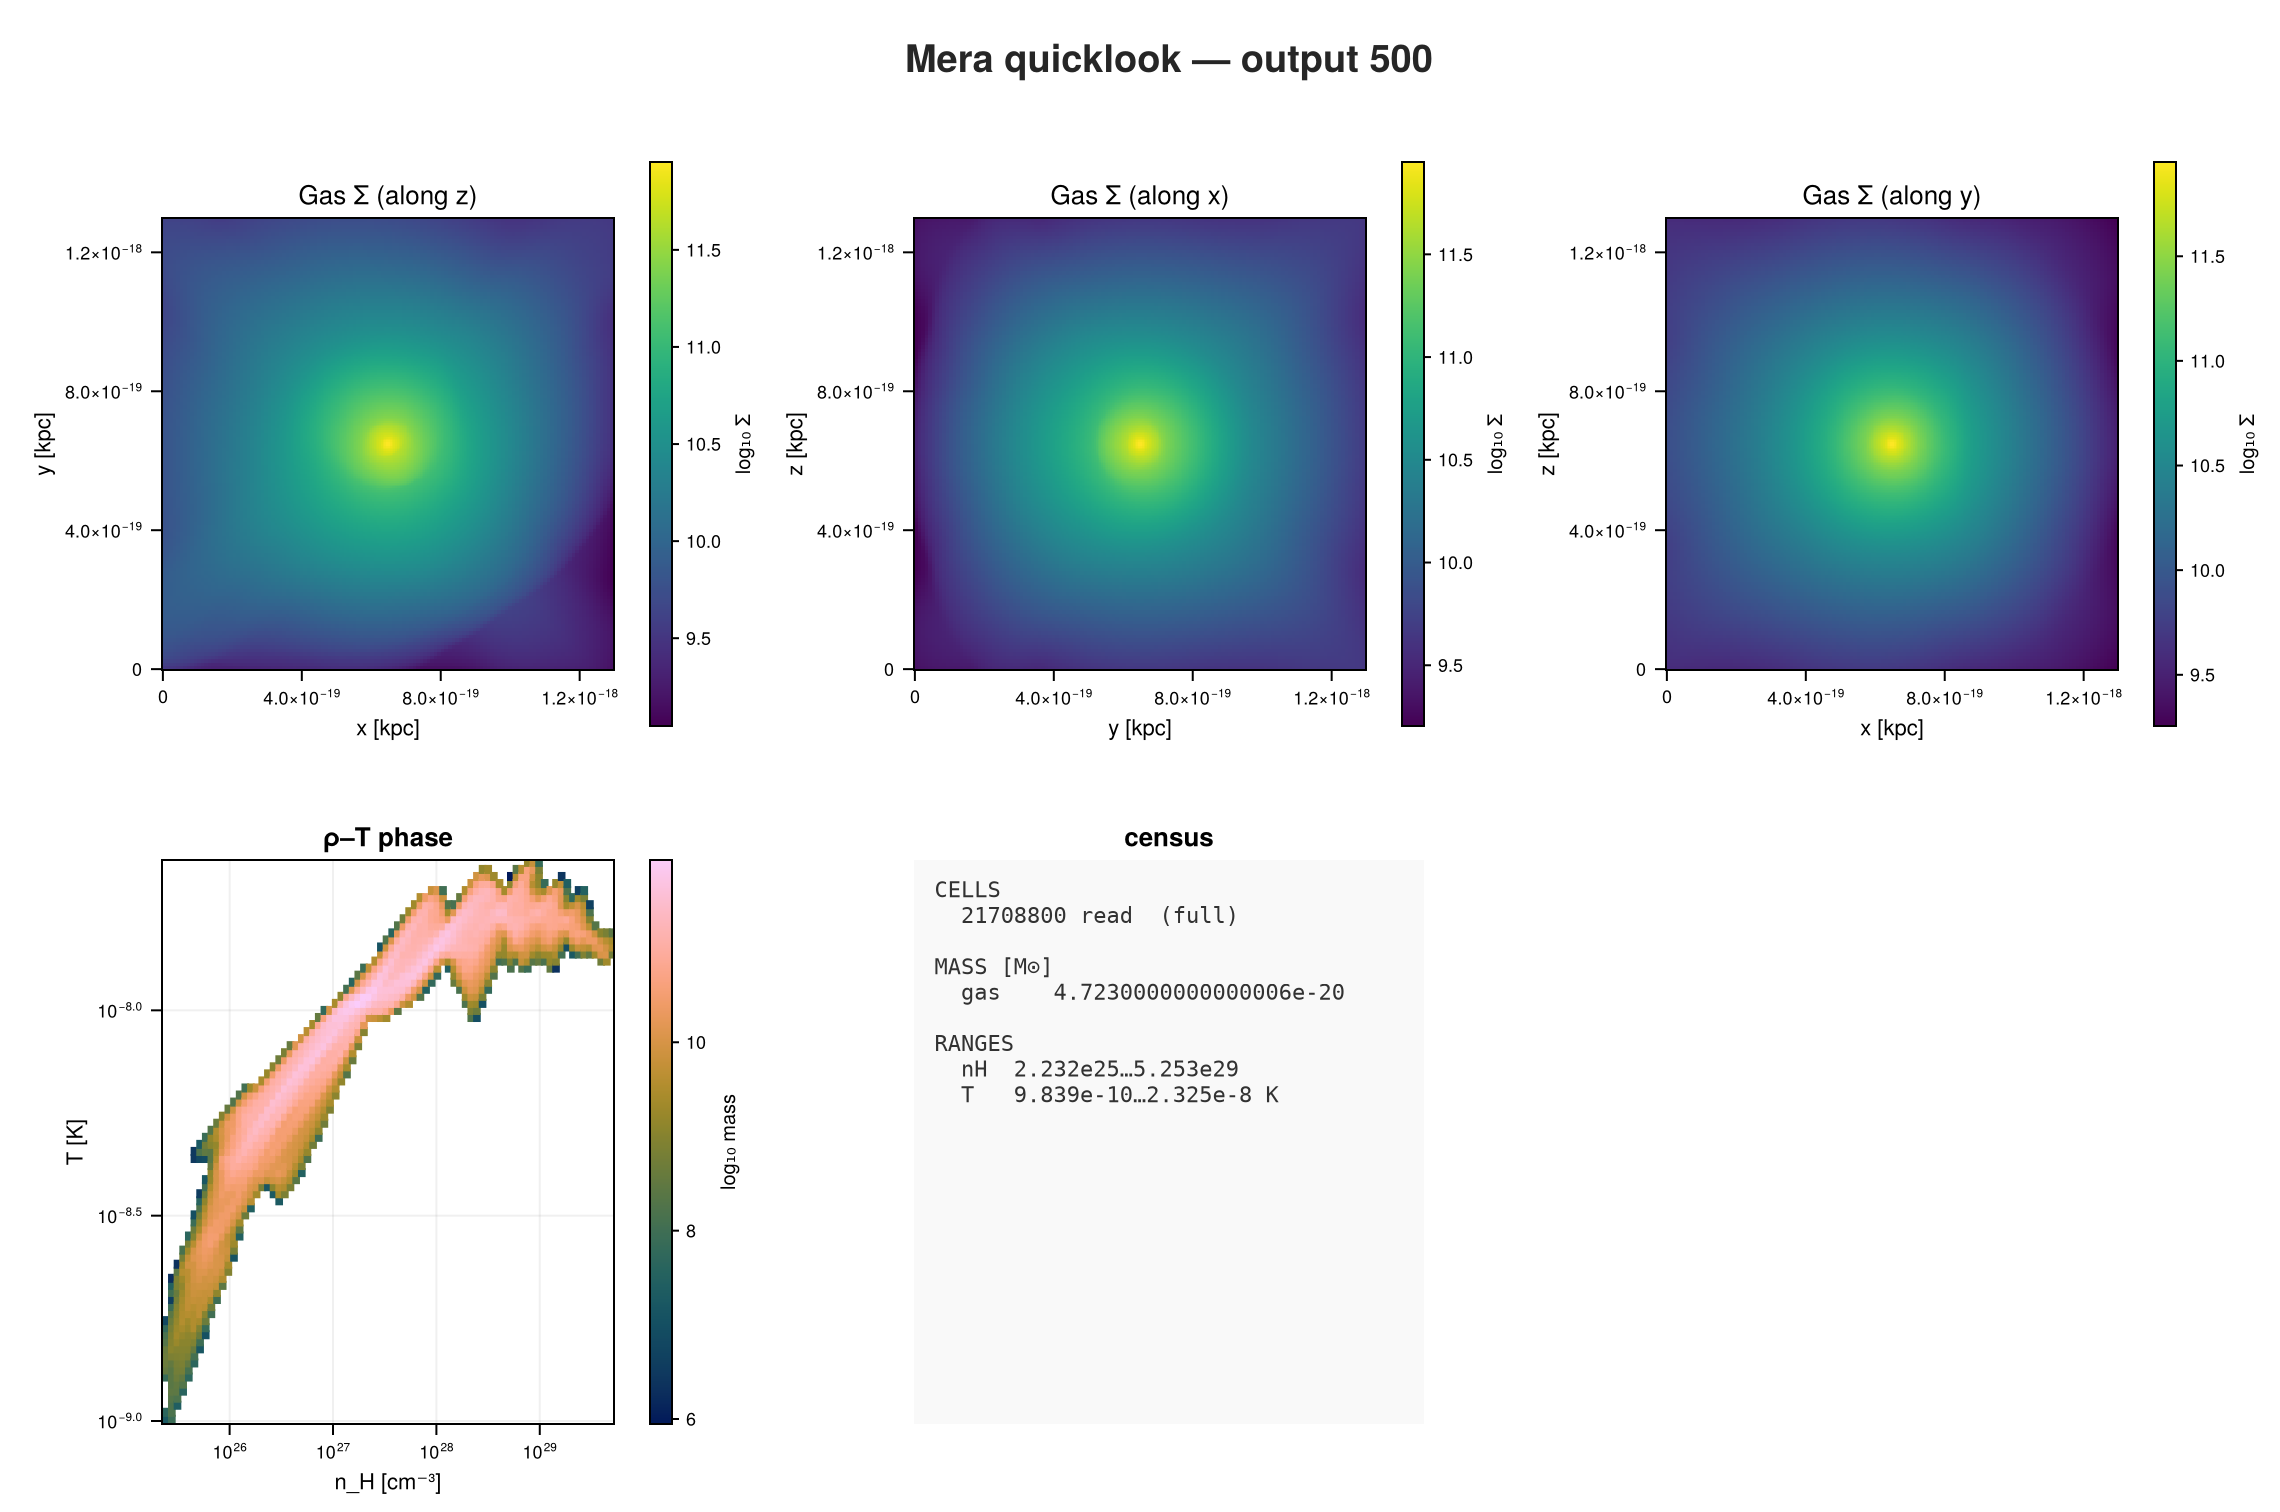

In [2]:
quicklookplot(ql)


Unlike the two previous pages, the density-temperature diagram here has real structure. This run
has a genuine spread of temperatures, so the plane fills instead of collapsing to a line.

!!! warning "This run is in code units"
    Athena++ keeps its unit constants in the problem setup, not in the output, so Mera cannot
    read them and treats one code unit as one CGS unit. Anything printed in kpc or solar masses
    above is therefore arithmetic rather than physics. Pass `unit_length=`, `unit_density=` and
    `unit_velocity=` if you know them; everything below stays in code units, which is honest for
    a turbulence box.


## 2. The details: `getinfo`


In [3]:
info = getinfo(500, path);


[Mera]: 2026-09-15T19:36:37.161

Code: Athena++
output: 500  time: 5000.0 [code units]
root grid: 128³ (level 7), MaxLevel 4 ⇒ levels 7:11, boxlen = 4000.0
MeshBlocks: 5300   variables: (rho, p, vx, vy, vz, bx, by, bz)
-------------------------------------------------------
[Mera]: composition not recorded by this format; using X = 0.76, mu = 1.32 (RAMSES convention) for :nH and :T. Change with setcomposition!(info; X_frac=…, mu=…).


In [4]:
info.simcode, info.levelmin, info.levelmax, info.variable_list


("Athena++", 7, 11, [:rho, :p, :vx, :vy, :vz, :bx, :by, :bz])

Eight variables, including a magnetic field, and **five** refinement levels.


## 3. What else could be loaded?


In [5]:
capabilities(info)


2-element Vector{Symbol}:
 :info
 :hydro

## 4. Load the gas

About 22 million cells. On a laptop this takes some tens of seconds and a few GB; Mera reads the
MeshBlocks and keeps only leaf cells.


In [6]:
gas = gethydro(info);


[Mera]: Athena++ hydro 21708800 cells, vars rho, p, vx, vy, vz, bx, by, bz

## 5. The refinement

`amroverview` is the quickest way to see how the grid is built.


In [7]:
amroverview(gas)


Counting...


Table with 5 rows, 3 columns:
level  cells     cellsize
─────────────────────────
7      1835008   31.25
8      1654784   15.625
9      2732032   7.8125
10     5165056   3.90625
11     10321920  1.95312

Each level halves the cell size, and the cell count grows with it: most of the data sits at the
finest level. Coarse cells that were refined away are not in the table at all, because Mera keeps
**leaf cells only**, every point covered exactly once.


In [8]:
gas.data


Table with 21708800 rows, 12 columns:
Columns:
#   colname  type
────────────────────
1   level    Int32
2   cx       Int32
3   cy       Int32
4   cz       Int32
5   rho      Float64
6   p        Float64
7   vx       Float64
8   vy       Float64
9   vz       Float64
10  bx       Float64
11  by       Float64
12  bz       Float64

## 6. Magnetic quantities

The file stores the field components. Everything built on them is derived when you ask.


In [9]:
extrema(getvar(gas, :bmag))         # field strength


(0.00233421313187907, 284.8326304134499)

In [10]:
extrema(getvar(gas, :beta))         # plasma beta, thermal over magnetic pressure


(2.8932108195477637, 1.381807941683557e8)

β runs from a few to more than 10⁸, so this box contains both strongly magnetised gas and regions
where the field is irrelevant. That range is the reason to look at β rather than at |B| alone.


## 7. A projection

Column density along z, on a fixed 256² grid.


In [11]:
proj = projection(gas, :sd, direction=:z, res=256);
size(proj.maps[:sd])


[Mera]: 2026-09-15T19:37:22.269



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [cm] :: 4000.0 [cm]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [cm] :: 4000.0 [cm]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [cm] :: 4000.0 [cm]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 256^2
Map size: 256 x 256
Pixel size: 15.625 [cm]
Simulation min.: 1.953 [cm]

Available threads: 8


Requested max_threads: 8
Variables: 1 (sd)
Processing mode: Sequential (single thread)


(256, 256)

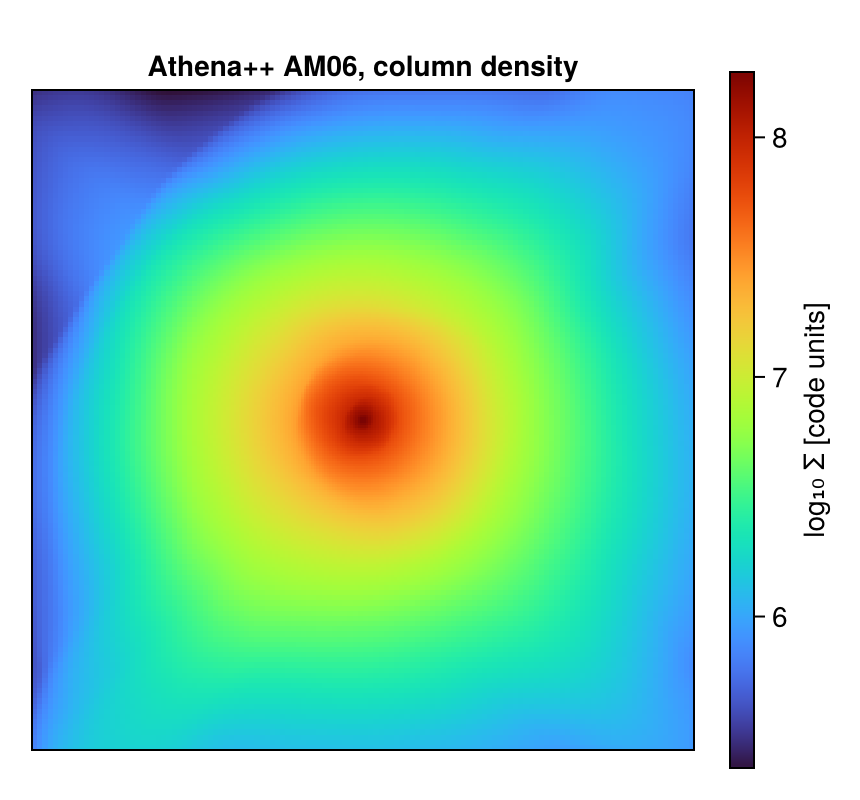

In [12]:
fig = Figure(size=(430, 400))
ax  = Axis(fig[1,1]; title="Athena++ AM06, column density", aspect=DataAspect())
hidedecorations!(ax)
hm = heatmap!(ax, log10.(proj.maps[:sd]'); colormap=:turbo)
Colorbar(fig[1,2], hm, label="log₁₀ Σ [code units]")
fig


## Where to go next

The same calls as on every other code, on five refinement levels and 22 million cells, with
magnetic quantities derived rather than stored.

From here every tutorial on this site applies unchanged.
